# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

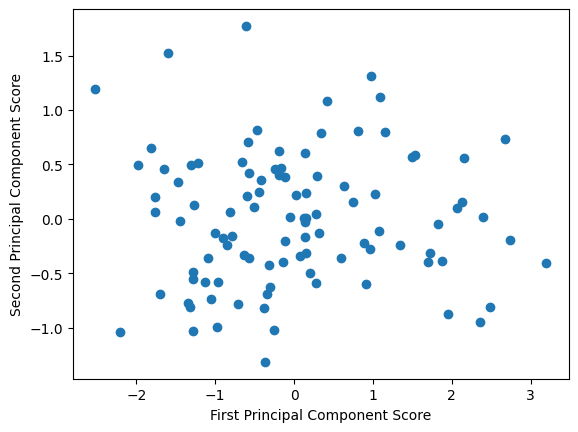

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

In [4]:
from google.colab import files
flight_delay = files.upload()


Saving Flight_delay.csv to Flight_delay.csv


In [5]:
flight_delay = pd.read_csv('Flight_delay.csv')
flight_delay.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [6]:
print(flight_delay.columns)

Index(['DayOfWeek', 'Date', 'DepTime', 'ArrTime', 'CRSArrTime',
       'UniqueCarrier', 'Airline', 'FlightNum', 'TailNum', 'ActualElapsedTime',
       'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin',
       'Org_Airport', 'Dest', 'Dest_Airport', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')


In [7]:
day_map = {
    1: "Mon", 2: "Tue", 3: "Wed",
    4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"
}

In [8]:
flight_delay["day_name"] = flight_delay["DayOfWeek"].map(day_map)

In [9]:
summary = flight_delay.groupby("day_name").agg(
    avg_delay=("ArrDelay", "mean"),
    num_flights=("ArrDelay", "count")
).reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]).reset_index()
summary


,day_name,avg_delay,num_flights
0,Mon,61.417613,70254
1,Tue,64.648694,65934
2,Wed,57.182729,63055
3,Thu,58.031849,75011
4,Fri,62.748101,88972
5,Sat,59.933976,51330
6,Sun,61.684677,69995


In [10]:
sizes = summary["num_flights"] * 0.05
worst_day = summary.loc[summary["avg_delay"].idxmax(), "day_name"]
colors = ["#2a6fdb" if d == worst_day else "#d3d3d3" for d in summary["day_name"]]

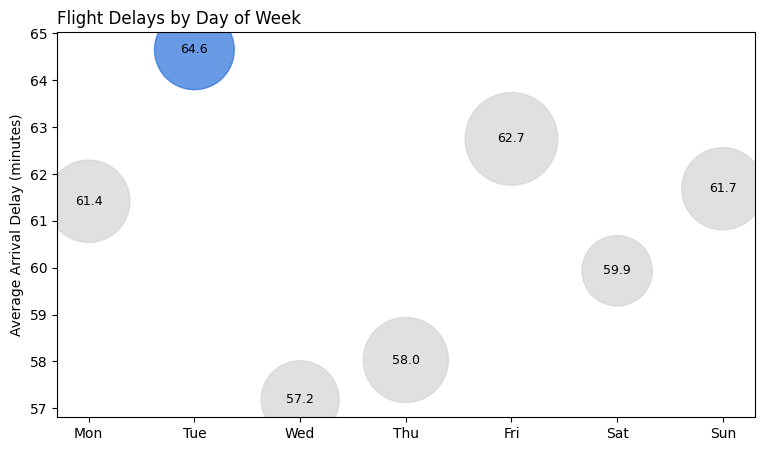

In [11]:
plt.figure(figsize=(9,5))
plt.scatter(
    summary["day_name"],
    summary["avg_delay"],
    s=sizes,
    c=colors,
    alpha=0.7
)

for i, row in summary.iterrows():
    plt.text(row["day_name"], row["avg_delay"],
             f"{row['avg_delay']:.1f}",
             ha='center', va='center', fontsize=9)
plt.xlabel("")
plt.ylabel("Average Arrival Delay (minutes)")
plt.title("Flight Delays by Day of Week", loc='left')

plt.show()

BAR graph for Airline delays by days of the week

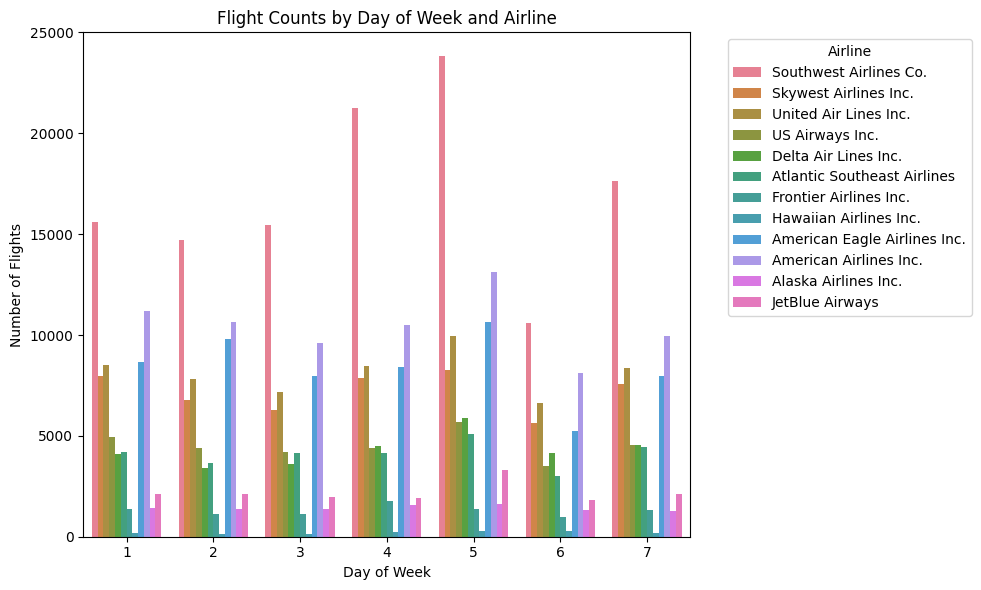

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=flight_delay,
    x="DayOfWeek",      # make sure this column exists
    hue="Airline"         # airline column
)

plt.title("Flight Counts by Day of Week and Airline")
plt.xlabel("Day of Week")
plt.ylabel("Number of Flights")
plt.legend(title="Airline", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

The hue is very pretty here, not sure its the best for visual representation for the different airlines. Here we see that Southwest is consistently late and Hawaiian and Frontier are the least late consistantly every day of the week.

In [20]:
flight_delay.describe()

,DayOfWeek,DepTime,ArrTime,CRSArrTime,FlightNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Distance,TaxiIn,TaxiOut,Cancelled,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.0,484551.0,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000
mean,3.991605,1564.477865,1617.784438,1652.129929,2139.207386,134.810422,131.400761,108.877134,60.907764,57.498086,752.142689,6.782413,19.150876,0.0,0.0,17.419440,3.153284,13.599421,0.082033,26.653587
std,1.971466,452.235219,583.637660,466.096216,1812.677071,74.070374,71.542531,70.113513,56.975420,55.991012,571.631124,5.555816,15.309747,0.0,0.0,39.417893,19.503657,31.454655,1.884774,40.535994
min,1.000000,1.000000,1.000000,1.000000,1.000000,15.000000,-21.000000,0.000000,15.000000,6.000000,31.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1234.000000,1327.000000,1339.000000,629.000000,80.000000,79.000000,57.000000,25.000000,23.000000,331.000000,4.000000,11.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,1620.000000,1737.000000,1723.000000,1514.000000,116.000000,114.000000,90.000000,42.000000,40.000000,599.000000,5.000000,15.000000,0.0,0.0,2.000000,0.000000,1.000000,0.000000,13.000000
75%,6.000000,1928.000000,2049.000000,2025.000000,3683.000000,168.000000,162.000000,139.000000,76.000000,72.000000,992.000000,8.000000,22.000000,0.0,0.0,19.000000,0.000000,13.000000,0.000000,36.000000
max,7.000000,2400.000000,2400.000000,2359.000000,8403.000000,727.000000,602.000000,609.000000,1707.000000,1710.000000,4502.000000,207.000000,383.000000,0.0,0.0,1707.000000,1148.000000,1357.000000,392.000000,1254.000000


In [21]:
flight_delay['Airline'].value_counts()

,count
Airline,
Southwest Airlines Co.,119048
American Airlines Inc.,73053
American Eagle Airlines Inc.,58698
United Air Lines Inc.,56896
Skywest Airlines Inc.,50384
US Airways Inc.,31755
Delta Air Lines Inc.,30220
Atlantic Southeast Airlines,28678
JetBlue Airways,15364


This dataset is only expressing flight delays, not the number of total flights an airline makes on a given day or a given week. My assumptions are Hawaiian airlines doesn't have as many flights as Southwest for example. Less flights means less oppurtunity to have delays.  

I think it would only be fair to find a dataset on the total flights each airline has per day per week. I'm not going to do that for this exercise. But it should be something considered when completing the EDA.  

Next, diving into the reasons for flight delays and the amount of time the delay was so make a prediction on what airline you should book for your next trip. Specifically if youre going to have a layover because you don't want any delays for that travel.

#PCA

In [12]:
df_numeric = flight_delay.select_dtypes(include=["int64", "float64"])
df_numeric = df_numeric.dropna()

#numeric values only and drop missing values

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

#standardize

In [14]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(explained_var)

print("\nCumulative variance:")
print(np.cumsum(explained_var))

Explained variance ratio:
[2.31477098e-01 1.50515120e-01 1.16641510e-01 8.66212086e-02
 6.46254435e-02 5.62776932e-02 5.57820633e-02 5.53808566e-02
 5.36052936e-02 4.40672359e-02 3.43852554e-02 3.21778652e-02
 1.49899802e-02 2.41228606e-03 1.04109043e-03 7.15452841e-11
 1.04844220e-16 9.63032436e-18 3.54458778e-18 0.00000000e+00]

Cumulative variance:
[0.2314771  0.38199222 0.49863373 0.58525494 0.64988038 0.70615807
 0.76194014 0.81732099 0.87092629 0.91499352 0.94937878 0.98155664
 0.99654662 0.99895891 1.         1.         1.         1.
 1.         1.        ]


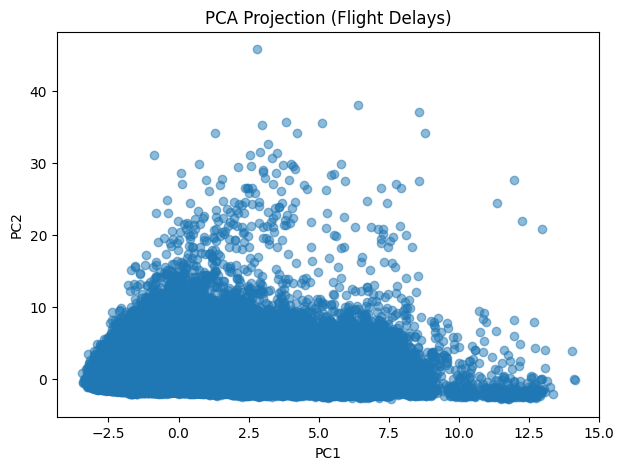

In [15]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (Flight Delays)")

plt.show()

I could reduce this dataset by a lot of components.  There is plenty of redundancy in the columns and this creates noise while trying to display the information.  Looks like after 12 components it fizzes out.

#Linear Regression

##Conclusions: Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

I believe that the data is useful, along with other datasets you could predict the possibility of a flight being cancelled if its on a specific day of the week and with certain airlines.  Weather didnt seem to be an issue, carrier delays and late aircraft seemed to be the largest issue. I suppose the airline company could do further research into whats casuing their carrier delays. Pilots and attendants being late, cleaning a dirty plane, fueling the engine, luggage loading?

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

In [16]:
import seaborn as sns

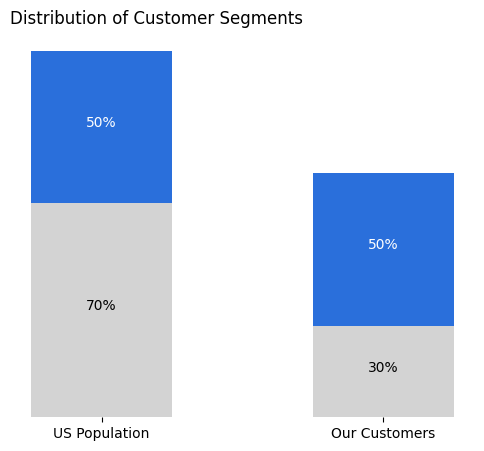

In [17]:
labels = ["Other Segments", "Segments 3–5"]

us_values = [16+7+32+15, 10+10+10]   # 70, 30
cust_values = [9+10+20+11, 15+18+17] # 50, 50

x = [0, 1]

plt.figure(figsize=(6,5))

# Bars
plt.bar([0,1], us_values, color="#d3d3d3", width=0.5)
plt.bar([0,1], cust_values, bottom=us_values, color="#2a6fdb", width=0.5)

# Labels
for i in range(2):
    plt.text(i, us_values[i]/2, f"{us_values[i]}%", ha='center')
    plt.text(i, us_values[i] + cust_values[i]/2, f"{cust_values[i]}%", ha='center', color="white")

# X labels
plt.xticks([0,1], ["US Population", "Our Customers"])

# Remove clutter
plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Title
plt.title("Distribution of Customer Segments", loc='left')

plt.show()